<a href="https://colab.research.google.com/github/Y-o-o-Y/TimesNet-2D-CNN/blob/main/TimesNet_2D_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Runtime type 裡面設置請打開 T4 GPU 大概10分鐘能訓練完
# 論文參考: TimesNet Temporal 2D Variation Modeling for General Time Series Analysis
# 特徵工程可用可不用，我自己測試下來建議把他們都關掉，讓神經網路自己使用原始數據挖掘特徵

# 架構流程 1.FFT 傅立葉轉換 2.將1D時序摺疊成2D圖片 3.Standard 2D Spatial Convolution 卷積
# (Reversible Instance Normalization)
# 數據標準化後送進推論，然後再把佔存的均值和標準差復原原始量剛 out * std + mean
# 基本上就是 rolling z score 再輸入層之前，卷積完後再依暫存平均和標準差還原

# 模型穩定度好，不同的seed跑出的結果不會差太多
# 進行的樣本外交易測試，牛市通常表現不佳，return 幾乎是0，但不至於出現-50%
# 熊市和高波動市場表現優異，這裡先用2025 NVDA 做範例，資料夾有份檔案可以看交易表現 "TimesNet 回測"

# 交易信號生成:
# 我看殘差收斂的差不多正態就可以開始生成交易信號了，持倉時間平均5天以內
# T5預測值跟今天價格取log 差分然後和過去的殘差排名，如果大於當前窗口排名前10%就做多，反之毅然
# 邏輯上其實有點類似統計配對套利

# 未來可能的發展: 清大後來有一份3D卷機架構，也很有潛力，尤其是還引入了動態調整行業成分股的機制
# 但是要一次餵入3000支股票，3D卷機算力要求也更高，現行做不了實驗
# TimesNet 屬於確定性模型，點對點預測，之後還會研究不確性模型(時序擴散模型)



/tmp/ipykernel_6096/786935358.py:220: FutureWarning: YF.download() has changed argument auto_adjust default to True
  raw_data = yf.download(download_tickers, start=DATA_START_DATE, end=DATA_END_DATE)
[******                12%                       ]  2 of 16 completed

正在獲取數據 (Target: NVDA)...


[*********************100%***********************]  16 of 16 completed



>>> [跳過] 所有基礎統計特徵

>>> [跳過] Beta

>>> [跳過] 幾何特徵 (Lévy & Fréchet)
最終特徵列表 (16): ['NVDA', 'TSM', 'AVGO', 'MU', 'AMD', 'ASML', 'LRCX', 'KLAC', 'TXN', 'QCOM', 'AMAT', 'ADI', 'INTC', 'SNPS', 'CDNS', 'MRVL']
Mounted at /content/drive

>>> [訓練] 窗口: 256 天 (Features: 16)


/tmp/ipykernel_6096/786935358.py:529: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
/tmp/ipykernel_6096/786935358.py:537: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_6096/786935358.py:468: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=False):


...

PFI 基準 MSE: 0.003048
沒有統計特徵可分析。

>>> 正在準備暖機數據 (Pre-loading History)...
>>> 開始推論 (含暖機與測試期)...


Inference:   0%|          | 0/377 [00:00<?, ?it/s]/tmp/ipykernel_6096/786935358.py:701: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Inference: 100%|██████████| 377/377 [00:17<00:00, 21.24it/s]



暖機完成。初始種子池大小: 128 筆

>>> 正在生成訊號 (從 2025-01-01 第1天開始)...
訊號生成完成。共觸發 23 次極端值過濾。

   ★ 模型評估 (Out of Sample: 2025-01-01 ~ ) ★
1. Naive MSE   : 0.003485
2. Model MSE   : 0.004740
3. 改善幅度    : -36.01%



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

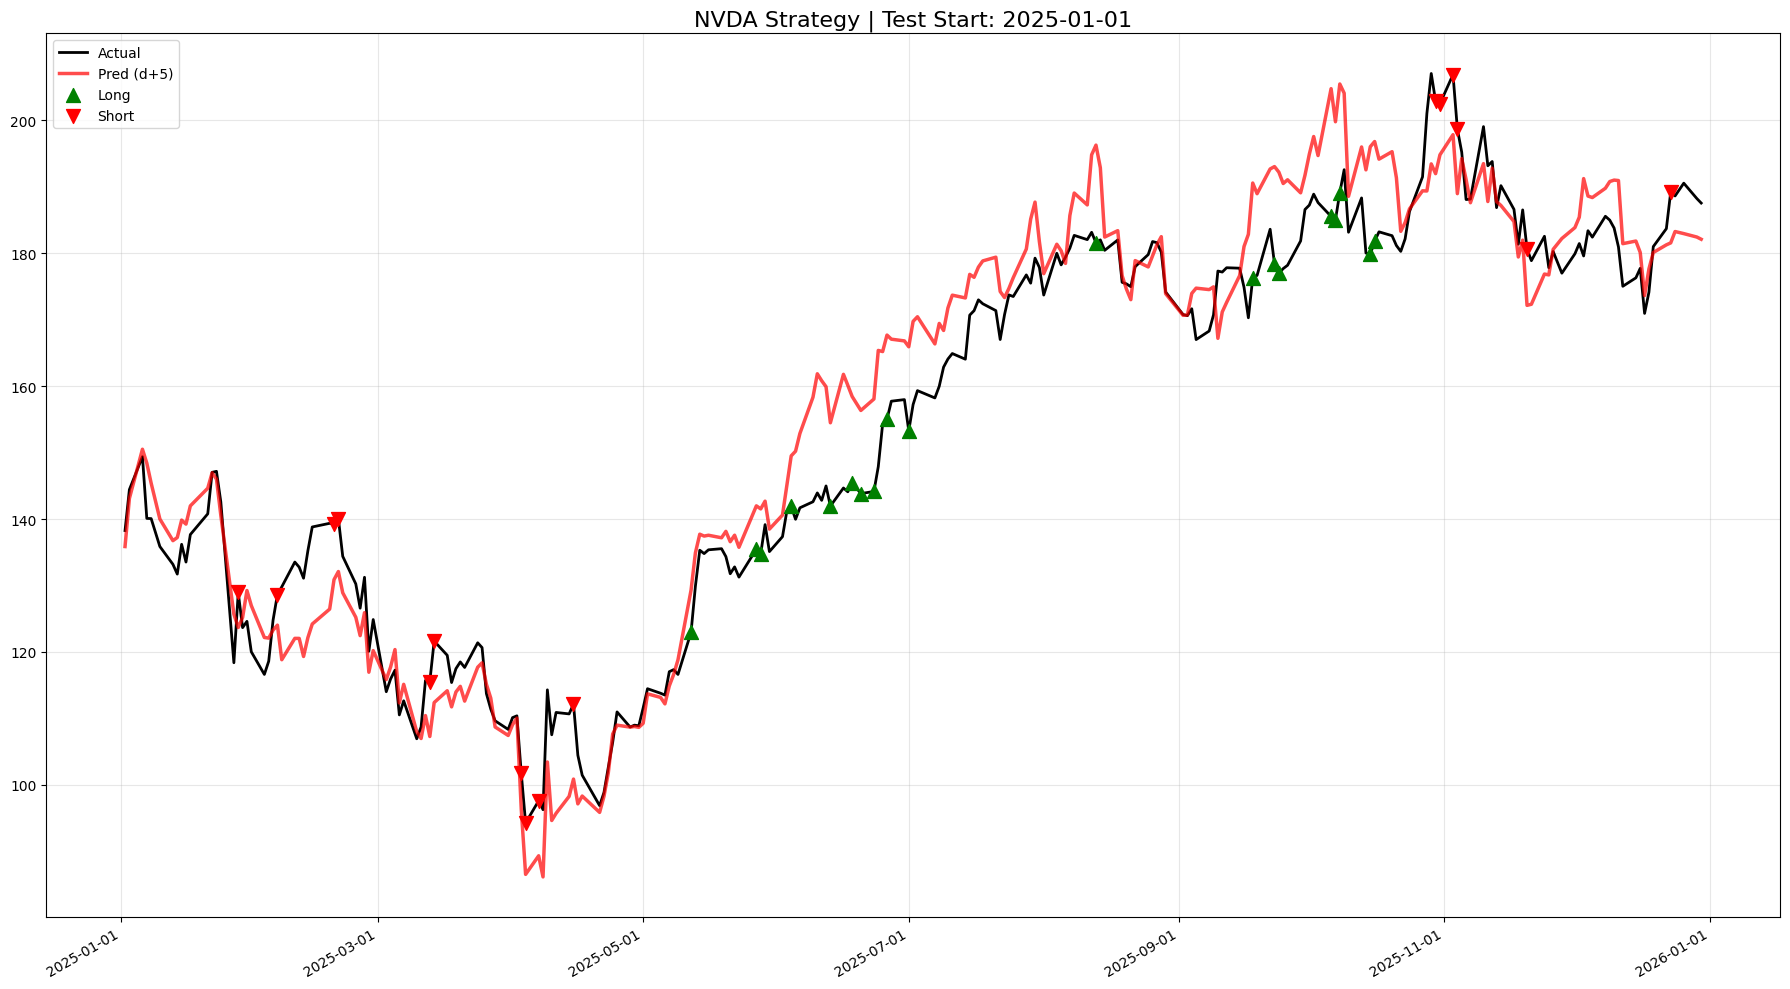

In [ ]:
#@title TimesNet 只用成分股
import torch
import torch.nn as nn
import torch.fft
from torch.cuda.amp import autocast, GradScaler
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Dataset
from sklearn.metrics import mean_squared_error
from sklearn.feature_selection import mutual_info_regression
import matplotlib.dates as mdates
from scipy.stats import energy_distance
from scipy.spatial.distance import pdist, squareform
from itertools import combinations
from tqdm import tqdm
from google.colab import files
from google.colab import drive
import os

# -----------------------------------------------------------------------------
# 0. 環境與參數設定
# -----------------------------------------------------------------------------
torch.manual_seed(42)
np.random.seed(42)

if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

# --- 設定區 ---
TARGET_TICKER = 'NVDA'
MARKET_FEATURES = [
    "TSM",
    "AVGO",
    "MU",
    "AMD",
    "ASML",
    "LRCX",
    "KLAC",
    "TXN",
    "QCOM",
    "AMAT",
    "ADI",
    "INTC",
    "SNPS",
    "CDNS",
    "MRVL"
]

DATA_START_DATE = '2007-05-01'
TRAIN_END_DATE  = '2024-07-01'
TEST_START_DATE = '2025-01-01'
DATA_END_DATE   = '2025-12-31'

# 交易用 THRESHOLD
PERCENTILE_THRESHOLD = 0.80
EXTREME_THRESHOLD = 0.95

TRAIN_NEW_MODEL = True

PRED_DAYS = 5
WARMUP_WINDOW = 128

# --- ★★★ 特徵工程控制板 (Feature Control Panel) ★★★ ---
# True = 開啟計算, False = 關閉
# 1. 基礎統計量 (細分控制)
ENABLE_ENERGY      = False  #@param {type:"boolean"} # Energy Distance
ENABLE_DCOR        = False  #@param {type:"boolean"} # Distance Correlation
ENABLE_DTW         = False  #@param {type:"boolean"} # Dynamic Time Warping
ENABLE_MI          = False  #@param {type:"boolean"} # Mutual Information

# 2. 進階特徵
ENABLE_BETA        = False  #@param {type:"boolean"} # Rolling Beta (Up/Down)
ENABLE_LEVY        = False  #@param {type:"boolean"} # Lévy Area (SymLog)
ENABLE_FRECHET     = False  #@param {type:"boolean"} # Fréchet Distance (Log1p)

# 特徵參數
WINDOW_STAT_SHORT = 60
WINDOW_STAT_LONG  = 128
BETA_QUANTILE     = 0.08
LEVY_WINDOWS      = [20, 60, 128, 256, 512]
FRECHET_WINDOWS   = [20, 60, 128]

# 模型參數
WINDOW_SIZES = [256, 512,720]
D_MODEL = 32
EPOCHS = 10
LR = 0.001
BATCH_SIZE = 32

# -----------------------------------------------------------------------------
# 1. 統計函數定義
# -----------------------------------------------------------------------------
def calc_dcor(x, y):
    """計算距離相關係數 (Distance Correlation)"""
    x = x[:, None]
    y = y[:, None]
    try:
        a = squareform(pdist(x))
        b = squareform(pdist(y))
        A = a - a.mean(axis=0)[None, :] - a.mean(axis=1)[:, None] + a.mean()
        B = b - b.mean(axis=0)[None, :] - b.mean(axis=1)[:, None] + b.mean()
        dcov2_xy = (A * B).mean()
        dcov2_xx = (A * A).mean()
        dcov2_yy = (B * B).mean()
        dcor = np.sqrt(dcov2_xy) / np.sqrt(np.sqrt(dcov2_xx) * np.sqrt(dcov2_yy) + 1e-9)
        return dcor
    except:
        return 0.0

def calc_dtw(s1, s2):
    """計算動態時間規整距離 (Simple DTW)"""
    n, m = len(s1), len(s2)
    dtw_matrix = np.zeros((n+1, m+1))
    dtw_matrix.fill(np.inf)
    dtw_matrix[0, 0] = 0
    for i in range(1, n+1):
        for j in range(1, m+1):
            cost = abs(s1[i-1] - s2[j-1])
            last_min = min(dtw_matrix[i-1, j], dtw_matrix[i, j-1], dtw_matrix[i-1, j-1])
            dtw_matrix[i, j] = cost + last_min
    return dtw_matrix[n, m]

def calc_mi(x, y, n_neighbors=3):
    """計算互信息 (Mutual Information)"""
    x = x.reshape(-1, 1)
    try:
        mi = mutual_info_regression(x, y, n_neighbors=n_neighbors, random_state=42)[0]
        return mi
    except:
        return 0.0

def calc_rolling_beta_metrics(target_seq, peer_seqs, window=128, quantile=0.08, ewma_span=20):
    """計算滾動的上行與下行 Beta"""
    n = len(target_seq)
    beta_up_list = np.zeros(n)
    beta_down_list = np.zeros(n)

    for i in range(window, n):
        t_seg = target_seq[i-window : i]
        current_step_betas_up = []
        current_step_betas_down = []

        for p_seq in peer_seqs:
            p_seg = p_seq[i-window : i]
            # --- Downside ---
            thresh_down = np.quantile(p_seg, quantile)
            mask_down = p_seg <= thresh_down
            if np.sum(mask_down) > 0:
                avg_t = np.mean(t_seg[mask_down])
                avg_p = np.mean(p_seg[mask_down])
                val = avg_t / (avg_p + 1e-9)
                current_step_betas_down.append(val)
            else:
                current_step_betas_down.append(1.0)
            # --- Upside ---
            thresh_up = np.quantile(p_seg, 1 - quantile)
            mask_up = p_seg >= thresh_up
            if np.sum(mask_up) > 0:
                avg_t = np.mean(t_seg[mask_up])
                avg_p = np.mean(p_seg[mask_up])
                val = avg_t / (avg_p + 1e-9)
                current_step_betas_up.append(val)
            else:
                current_step_betas_up.append(1.0)

        beta_down_list[i] = np.mean(current_step_betas_down)
        beta_up_list[i]   = np.mean(current_step_betas_up)

    b_up_series = pd.Series(beta_up_list).ewm(span=ewma_span).mean().values
    b_down_series = pd.Series(beta_down_list).ewm(span=ewma_span).mean().values
    b_up_series[:window] = 1.0
    b_down_series[:window] = 1.0
    return b_up_series, b_down_series

def calc_rolling_levy_area(series_target, series_ref, window):
    """計算滾動窗口內的 Lévy Area"""
    n = len(series_target)
    levy_area_list = np.zeros(n)
    vals_target = series_target.values
    vals_ref = series_ref.values

    for i in range(window, n):
        y_seg = vals_target[i-window : i]
        x_seg = vals_ref[i-window : i]
        y_norm = (y_seg - np.mean(y_seg)) / (np.std(y_seg) + 1e-9)
        x_norm = (x_seg - np.mean(x_seg)) / (np.std(x_seg) + 1e-9)
        term1 = x_norm[:-1] * y_norm[1:]
        term2 = x_norm[1:] * y_norm[:-1]
        area = 0.5 * np.sum(term1 - term2)
        levy_area_list[i] = area
    return levy_area_list

def calc_discrete_frechet(P, Q):
    """計算 Discrete Fréchet Distance (DP)"""
    n = len(P)
    m = len(Q)
    ca = np.full((n, m), -1.0)
    dist_matrix = np.abs(P[:, None] - Q[None, :])
    ca[0, 0] = dist_matrix[0, 0]
    for j in range(1, m): ca[0, j] = max(ca[0, j-1], dist_matrix[0, j])
    for i in range(1, n): ca[i, 0] = max(ca[i-1, 0], dist_matrix[i, 0])
    for i in range(1, n):
        for j in range(1, m):
            min_prev = min(ca[i-1, j], ca[i, j-1], ca[i-1, j-1])
            ca[i, j] = max(min_prev, dist_matrix[i, j])
    return ca[n-1, m-1]

# -----------------------------------------------------------------------------
# 2. 數據獲取與特徵工程
# -----------------------------------------------------------------------------
download_tickers = [TARGET_TICKER] + [t for t in MARKET_FEATURES if t != TARGET_TICKER]
feature_columns = list(download_tickers)

print(f"正在獲取數據 (Target: {TARGET_TICKER})...")
raw_data = yf.download(download_tickers, start=DATA_START_DATE, end=DATA_END_DATE)
df_final = pd.DataFrame(index=raw_data.index)

# A. 基礎價格處理 (Log Price)
for t in feature_columns:
    try:
        series = raw_data['Close'][t]
    except KeyError:
        if t == download_tickers[0] and len(download_tickers) == 1:
            series = raw_data['Close']
        else:
            raise KeyError(f"無法找到 {t} 的 Close 數據")
    series = series.ffill().bfill()
    df_final[t] = np.log(series + 1e-5)

# B. 準備 Returns 數據
returns_df = df_final[download_tickers].diff().dropna()
dates = returns_df.index
returns_values = returns_df.values
vals = returns_values
n_rows = len(vals)
tickers_for_dist = download_tickers

# =============================================================================
# C. ★ 控制板：基礎統計特徵 (Energy, dCor, DTW, MI) ★
# =============================================================================
# 只要有任何一個基礎特徵開啟，就進入計算迴圈
ANY_BASIC_STATS = (ENABLE_ENERGY or ENABLE_DCOR or ENABLE_DTW or ENABLE_MI)

if ANY_BASIC_STATS:
    print(f"\n>>> [開啟] 基礎統計特徵計算...")
    print(f"    - Energy: {ENABLE_ENERGY}")
    print(f"    - dCor:   {ENABLE_DCOR}")
    print(f"    - DTW:    {ENABLE_DTW}")
    print(f"    - MI:     {ENABLE_MI}")

    stats_results = []
    start_idx_loop = WINDOW_STAT_LONG

    for i in tqdm(range(start_idx_loop, n_rows + 1), desc="Basic Stats"):
        current_date = dates[i-1]

        # 準備切片
        slice_short = vals[i - WINDOW_STAT_SHORT : i]
        slice_long  = vals[i - WINDOW_STAT_LONG  : i]

        target_idx = tickers_for_dist.index(TARGET_TICKER)
        target_seq_short = slice_short[:, target_idx]
        target_seq_long  = slice_long[:, target_idx]

        # 用於暫存多資產的計算結果
        energy_list, dcor_list, dtw_list, mi_list = [], [], [], []

        for other_idx in range(len(tickers_for_dist)):
            if other_idx == target_idx: continue
            other_seq_short = slice_short[:, other_idx]
            other_seq_long = slice_long[:, other_idx]

            # 1. Energy
            if ENABLE_ENERGY:
                e_dist = energy_distance(target_seq_short, other_seq_short)
                energy_list.append(e_dist)

            # 2. dCor
            if ENABLE_DCOR:
                d_val = calc_dcor(target_seq_short, other_seq_short)
                dcor_list.append(d_val)

            # 3. DTW
            if ENABLE_DTW:
                t_norm = (target_seq_short - target_seq_short.mean()) / (target_seq_short.std() + 1e-9)
                o_norm = (other_seq_short - other_seq_short.mean()) / (other_seq_short.std() + 1e-9)
                dtw_val = calc_dtw(t_norm, o_norm)
                dtw_list.append(dtw_val)

            # 4. MI (Long Window)
            if ENABLE_MI:
                mi_val = calc_mi(target_seq_long, other_seq_long)
                mi_list.append(mi_val)

        # 彙整當日數據
        daily_stats = {'Date': current_date}

        if ENABLE_ENERGY:
            daily_stats['feat_Energy'] = np.mean(energy_list) if energy_list else 0
        if ENABLE_DCOR:
            daily_stats['feat_dCor']   = np.mean(dcor_list) if dcor_list else 0
        if ENABLE_DTW:
            daily_stats['feat_DTW']    = np.mean(dtw_list) if dtw_list else 0
        if ENABLE_MI:
            daily_stats['feat_MI']     = np.mean(mi_list) if mi_list else 0

        stats_results.append(daily_stats)

    # 轉為 DataFrame 並合併
    stats_df = pd.DataFrame(stats_results).set_index('Date')
    df_final = df_final.join(stats_df)

    # 根據開關將欄位加入 feature_columns，並做必要的 Log 處理
    if ENABLE_ENERGY:
        df_final['feat_Energy'] = np.log(df_final['feat_Energy'] + 1e-9)
        feature_columns.append('feat_Energy')

    if ENABLE_DCOR:
        feature_columns.append('feat_dCor')

    if ENABLE_DTW:
        df_final['feat_DTW'] = np.log(df_final['feat_DTW'] + 1e-9)
        feature_columns.append('feat_DTW')

    if ENABLE_MI:
        feature_columns.append('feat_MI')

else:
    print(f"\n>>> [跳過] 所有基礎統計特徵")

# =============================================================================
# D. ★ 控制板：Beta ★
# =============================================================================
if ENABLE_BETA:
    print(f"\n>>> [開啟] Beta (Up/Down)...")
    target_idx = tickers_for_dist.index(TARGET_TICKER)
    target_seq_full = returns_values[:, target_idx]
    peer_seqs_list = [returns_values[:, idx] for idx in range(len(tickers_for_dist)) if idx != target_idx]

    beta_up, beta_down = calc_rolling_beta_metrics(
        target_seq_full,
        peer_seqs_list,
        window=WINDOW_STAT_LONG,
        quantile=BETA_QUANTILE,
        ewma_span=20
    )

    beta_df = pd.DataFrame({
        'feat_Beta_Up': beta_up,
        'feat_Beta_Down': beta_down
    }, index=returns_df.index)

    df_final = df_final.join(beta_df)
    feature_columns.extend(['feat_Beta_Up', 'feat_Beta_Down'])
else:
    print(f"\n>>> [跳過] Beta")

# =============================================================================
# E. ★ 控制板：多尺度 Lévy Area & Fréchet ★
# =============================================================================
if ENABLE_LEVY or ENABLE_FRECHET:
    print(f"\n>>> [開啟] 幾何特徵計算 (Levy: {ENABLE_LEVY}, Frechet: {ENABLE_FRECHET})...")
    series_target = df_final[TARGET_TICKER]
    vals_target = series_target.values

    # 遍歷每一個市場特徵
    for m_ticker in MARKET_FEATURES:
        if m_ticker == TARGET_TICKER: continue
        print(f"    -> Pair: {TARGET_TICKER} vs {m_ticker}")
        series_ref = df_final[m_ticker]
        vals_ref = series_ref.values

        # --- 1. Lévy Area ---
        if ENABLE_LEVY:
            for w in tqdm(LEVY_WINDOWS, desc=f"Lévy ({m_ticker})", leave=False):
                col_name = f'feat_Levy_{m_ticker}_{w}d'
                raw_levy = calc_rolling_levy_area(series_target, series_ref, window=w)
                # SymLog 轉換
                final_feat = np.sign(raw_levy) * np.log1p(np.abs(raw_levy))
                df_final[col_name] = final_feat
                if col_name not in feature_columns:
                    feature_columns.append(col_name)

        # --- 2. Fréchet Distance ---
        if ENABLE_FRECHET:
            for w in tqdm(FRECHET_WINDOWS, desc=f"Fréchet ({m_ticker})", leave=False):
                col_name = f'feat_Frechet_{m_ticker}_{w}d'
                frechet_list = np.zeros(len(df_final))

                for i in range(w, len(df_final)):
                    seg_t = vals_target[i-w : i]
                    seg_r = vals_ref[i-w : i]

                    # Z-Score
                    seg_t_norm = (seg_t - np.mean(seg_t)) / (np.std(seg_t) + 1e-9)
                    seg_r_norm = (seg_r - np.mean(seg_r)) / (np.std(seg_r) + 1e-9)

                    raw_frechet = calc_discrete_frechet(seg_t_norm, seg_r_norm)
                    frechet_list[i] = np.log1p(raw_frechet) # Log1p 轉換

                df_final[col_name] = frechet_list
                if col_name not in feature_columns:
                    feature_columns.append(col_name)
else:
    print(f"\n>>> [跳過] 幾何特徵 (Lévy & Fréchet)")

# F. 最終整理
print(f"最終特徵列表 ({len(feature_columns)}): {feature_columns}")
df_final = df_final[feature_columns]
df_final.dropna(inplace=True)

# --- 數據切分 ---
df_train = df_final.loc[:TRAIN_END_DATE]
target_date = pd.Timestamp(TEST_START_DATE)
if target_date > df_final.index[-1]:
    test_start_idx = len(df_final) - 1
else:
    test_start_idx = df_final.index.searchsorted(target_date)

start_idx_with_warmup = test_start_idx - WARMUP_WINDOW - max(WINDOW_SIZES)
if start_idx_with_warmup < 0: start_idx_with_warmup = 0
strategy_execution_data = df_final.iloc[start_idx_with_warmup : ]

# -----------------------------------------------------------------------------
# 3. 模型與 Dataset
# -----------------------------------------------------------------------------
class SinglePointDataset(Dataset):
    def __init__(self, dataframe, input_window, pred_at=5):
        self.data = dataframe.values.astype(np.float32)
        self.input_window = input_window
        self.pred_at = pred_at
    def __len__(self):
        return len(self.data) - self.input_window - self.pred_at + 1
    def __getitem__(self, idx):
        x = self.data[idx : idx + self.input_window]
        y = self.data[idx + self.input_window + self.pred_at - 1 :
                      idx + self.input_window + self.pred_at]
        return x, y

class InceptionBlockV1(nn.Module):
    def __init__(self, in_channels, out_channels, num_kernels=6):
        super(InceptionBlockV1, self).__init__()
        self.convs = nn.ModuleList([
            nn.Conv2d(in_channels, out_channels, kernel_size=2*i+1, padding=i)
            for i in range(num_kernels)
        ])
    def forward(self, x):
        res_list = [conv(x) for conv in self.convs]
        return torch.stack(res_list, dim=-1).mean(-1)

class TimesBlock(nn.Module):
    def __init__(self, input_len, d_model, k=5):
        super(TimesBlock, self).__init__()
        self.k = k
        self.seq_len = input_len
        self.conv = nn.Sequential(
            InceptionBlockV1(d_model, d_model),
            nn.GELU(),
            InceptionBlockV1(d_model, d_model)
        )
    def forward(self, x):
        B, T, N = x.size()
        with autocast(enabled=False):
            fft_x = torch.fft.rfft(x.float(), dim=1)
            avg_amplitude = torch.abs(fft_x).mean(dim=-1)
        avg_amplitude[:, 0] = 0
        topk_values, topk_indices = torch.topk(avg_amplitude.mean(0), self.k)
        period_lengths = (self.seq_len / (topk_indices + 1e-5)).int()
        res = []
        for i in range(self.k):
            period = period_lengths[i].item()
            if period < 2: period = 2
            padding_len = (period - (self.seq_len % period)) % period
            x_padded = torch.cat([x, torch.zeros(B, padding_len, N, device=x.device)], dim=1)
            num_rows = x_padded.shape[1] // period
            x_2d = x_padded.view(B, num_rows, period, N).permute(0, 3, 1, 2).contiguous()
            out_2d = self.conv(x_2d)
            out_1d = out_2d.permute(0, 2, 3, 1).contiguous().view(B, -1, N)
            res.append(out_1d[:, :self.seq_len, :])
        res = torch.stack(res, dim=-1)
        weights = torch.softmax(topk_values, dim=-1).view(1, 1, 1, -1).to(x.device)
        return (res * weights).sum(-1) + x

class TimesNet(nn.Module):
    def __init__(self, num_features, input_len, d_model=32, num_layers=2):
        super(TimesNet, self).__init__()
        self.embedding = nn.Linear(num_features, d_model)
        self.layers = nn.ModuleList([TimesBlock(input_len, d_model) for _ in range(num_layers)])
        self.output_projection = nn.Linear(d_model, num_features)
        self.refine = nn.Linear(input_len, 1)

    def forward(self, x):
        mean = x.mean(dim=1, keepdim=True)
        std = torch.sqrt(x.var(dim=1, keepdim=True) + 1e-5)
        x_enc = (x - mean) / std
        enc_out = self.embedding(x_enc)
        for layer in self.layers:
            enc_out = layer(enc_out)
        out = self.output_projection(enc_out).permute(0, 2, 1)
        out = self.refine(out).permute(0, 2, 1)
        return out * std + mean

# -----------------------------------------------------------------------------
# 4. 訓練流程
# -----------------------------------------------------------------------------
drive.mount('/content/drive')
MODEL_SAVE_DIR = '/content/drive/My Drive/Colab_Models/TimesNet_Stock_Final/'
os.makedirs(MODEL_SAVE_DIR, exist_ok=True)

trained_models = {}
num_features_count = len(feature_columns)

for window in WINDOW_SIZES:
    model_path = f"{MODEL_SAVE_DIR}timesnet_w{window}_{TARGET_TICKER}_Config.pth"
    model = TimesNet(num_features=num_features_count, input_len=window, d_model=D_MODEL).to(device)

    if TRAIN_NEW_MODEL:
        print(f"\n>>> [訓練] 窗口: {window} 天 (Features: {num_features_count})")
        ds = SinglePointDataset(df_train, window, pred_at=PRED_DAYS)
        loader = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=True, pin_memory=True)

        optimizer = torch.optim.Adam(model.parameters(), lr=LR)
        criterion = nn.MSELoss()
        scaler = GradScaler()

        for epoch in range(EPOCHS):
            model.train()
            epoch_loss = 0
            for bx, by in loader:
                bx, by = bx.to(device), by.to(device)
                optimizer.zero_grad(set_to_none=True)
                with autocast():
                    out = model(bx)
                    loss = criterion(out, by)
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
                epoch_loss += loss.item()
            if (epoch+1) % 5 == 0:
                print(f"Epoch {epoch+1}/{EPOCHS} | Loss: {epoch_loss/len(loader):.6f}")

        torch.save(model.state_dict(), model_path)
    else:
        # 注意：如果特徵數量改變，讀取舊模型會報錯，必須重訓
        if os.path.exists(model_path):
            print(f"\n>>> [讀取] 窗口 {window}...")
            try:
                model.load_state_dict(torch.load(model_path, map_location=device))
                model.eval()
            except Exception as e:
                print(f"模型架構不匹配 (可能是特徵數變了)，請設 TRAIN_NEW_MODEL=True 重訓。\n錯誤: {e}")
                continue
        else:
            print(f"找不到模型 {model_path}，跳過。")
            continue
    trained_models[window] = model

# -----------------------------------------------------------------------------
# 加插功能：計算特徵重要性 (Permutation Feature Importance)
# -----------------------------------------------------------------------------
def calculate_permutation_importance(model, loader, device, feature_names):
    model.eval()
    criterion = nn.MSELoss()

    # 1. 計算基準誤差
    original_loss = 0
    num_batches = 0
    all_x = []
    all_y = []

    with torch.no_grad():
        for bx, by in loader:
            bx, by = bx.to(device), by.to(device)
            all_x.append(bx)
            all_y.append(by)
            with autocast():
                out = model(bx)
                loss = criterion(out, by)
            original_loss += loss.item()
            num_batches += 1

    baseline_mse = original_loss / num_batches
    print(f"PFI 基準 MSE: {baseline_mse:.6f}")

    importances = {}
    full_x = torch.cat(all_x, dim=0)
    full_y = torch.cat(all_y, dim=0)

    # 測試所有統計特徵
    target_feats = [f for f in feature_names if 'feat_' in f]
    target_indices = [feature_names.index(f) for f in target_feats]

    if not target_indices:
        print("沒有統計特徵可分析。")
        return {}

    print("正在計算特徵重要性 (PFI)...")

    for feat_idx in tqdm(target_indices, desc="Permuting"):
        feat_name = feature_names[feat_idx]
        x_permuted = full_x.clone()
        perm_indices = torch.randperm(x_permuted.size(0))
        x_permuted[:, :, feat_idx] = x_permuted[perm_indices, :, feat_idx]

        perm_loss = 0
        batch_counts = 0
        dataset_size = x_permuted.size(0)
        curr_ptr = 0

        while curr_ptr < dataset_size:
            end_ptr = min(curr_ptr + BATCH_SIZE, dataset_size)
            bx_p = x_permuted[curr_ptr:end_ptr].to(device)
            by_p = full_y[curr_ptr:end_ptr].to(device)

            with torch.no_grad():
                with autocast():
                    out = model(bx_p)
                    loss = criterion(out, by_p)
                perm_loss += loss.item()
            curr_ptr += BATCH_SIZE
            batch_counts += 1

        perm_mse = perm_loss / batch_counts
        importances[feat_name] = perm_mse - baseline_mse

    return importances

# 執行 PFI 分析
test_window = max(WINDOW_SIZES)
if test_window in trained_models:
    # 計算所需的絕對最小長度
    min_needed = test_window + PRED_DAYS + 1

    # 預設取 20%，但如果 20% 不夠，就強制取 min_needed
    val_size = int(len(df_train) * 0.2)
    if val_size < min_needed:
        val_size = min_needed
        print(f"ℹ️ 偵測到資料量較少，已將驗證集調整為最小需求：{val_size} 天")

    val_data = df_train.iloc[-val_size:]
    val_ds = SinglePointDataset(val_data, test_window, pred_at=PRED_DAYS)

    if len(val_ds) > 0:
        val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
        imp_scores = calculate_permutation_importance(
            trained_models[test_window],
            val_loader,
            device,
            feature_columns
        )

    if imp_scores:
        imp_df = pd.DataFrame(list(imp_scores.items()), columns=['Feature', 'Importance'])
        imp_df = imp_df.sort_values(by='Importance', ascending=True)

        plt.figure(figsize=(10, 8))
        plt.barh(imp_df['Feature'], imp_df['Importance'], color='skyblue')
        plt.title(f'Feature Importance (PFI) - Window {test_window}')
        plt.xlabel('Increase in MSE (Higher is Better)')
        plt.grid(axis='x', linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.show()

# -----------------------------------------------------------------------------
# 5. 推論與評估
# -----------------------------------------------------------------------------
print("\n>>> 正在準備暖機數據 (Pre-loading History)...")

warmup_start_idx = test_start_idx - WARMUP_WINDOW - max(WINDOW_SIZES)
if warmup_start_idx < 0: warmup_start_idx = 0

full_inference_data = df_final.iloc[warmup_start_idx : ].copy()
inference_vals = full_inference_data.values.astype(np.float32)
dates_map = full_inference_data.index

predictions_history = []
mse_records = []
initial_history_pool = []

print(">>> 開始推論 (含暖機與測試期)...")

with torch.inference_mode():
    start_loop = max(WINDOW_SIZES)
    total_steps = len(full_inference_data)

    for i in tqdm(range(start_loop, total_steps), desc="Inference"):
        current_date = dates_map[i]
        current_actual_log = full_inference_data.iloc[i][TARGET_TICKER]

        # A. 模型預測
        model_preds = []
        for w, model in trained_models.items():
            model.eval()
            input_seq = inference_vals[i-w+1 : i+1]
            x = torch.from_numpy(input_seq).unsqueeze(0).to(device)
            with autocast():
                pred_log = model(x)
            model_preds.append(pred_log[0, 0, 0].cpu().item())

        ensemble_pred_log = np.mean(model_preds)
        expected_return = ensemble_pred_log - current_actual_log

        if current_date < pd.Timestamp(TEST_START_DATE):
            initial_history_pool.append(expected_return)
        else:
            predictions_history.append({
                'Date': current_date,
                'Actual_Price': np.exp(current_actual_log),
                'Actual_Log': current_actual_log,
                'Exp_Return': expected_return
            })

            target_idx = i - 1 + PRED_DAYS
            if target_idx < total_steps:
                target_actual_log = full_inference_data.iloc[target_idx][TARGET_TICKER]
                mse_records.append({
                    'Date': dates_map[target_idx],
                    'Pred_Log': ensemble_pred_log,
                    'Actual_Log': target_actual_log,
                    'Current_Log': current_actual_log
                })

strat_df = pd.DataFrame(predictions_history).set_index('Date')
print(f"\n暖機完成。初始種子池大小: {len(initial_history_pool)} 筆")

# --- 訊號生成 ---
signals = []
outlier_count = 0
history_returns = list(initial_history_pool)

print(f"\n>>> 正在生成訊號 (從 {TEST_START_DATE} 第1天開始)...")

for i in range(len(strat_df)):
    current_val = strat_df['Exp_Return'].iloc[i]

    if len(history_returns) > WARMUP_WINDOW:
        recent_pool = history_returns[-WARMUP_WINDOW:]
    else:
        recent_pool = history_returns

    pool_series = pd.Series(recent_pool)
    pos_samples = pool_series[pool_series > 0]
    neg_samples = pool_series[pool_series < 0]

    signal = 'Hold'

    if current_val > 0 and not pos_samples.empty:
        long_lower = pos_samples.quantile(PERCENTILE_THRESHOLD)
        long_upper = pos_samples.quantile(EXTREME_THRESHOLD)
        if long_lower < current_val < long_upper:
            signal = 'Long'
        elif current_val >= long_upper:
            signal = 'Hold'
            outlier_count += 1

    elif current_val < 0 and not neg_samples.empty:
        short_upper = neg_samples.quantile(1 - PERCENTILE_THRESHOLD)
        short_lower = neg_samples.quantile(1 - EXTREME_THRESHOLD)
        if short_lower < current_val < short_upper:
            signal = 'Short'
        elif current_val <= short_lower:
            signal = 'Hold'
            outlier_count += 1

    signals.append(signal)
    history_returns.append(current_val)

strat_df['Signal'] = signals
print(f"訊號生成完成。共觸發 {outlier_count} 次極端值過濾。")

# --- 評估結果 ---
if len(mse_records) > 0:
    mse_df = pd.DataFrame(mse_records)
    model_mse = mean_squared_error(mse_df['Actual_Log'], mse_df['Pred_Log'])
    naive_mse = mean_squared_error(mse_df['Actual_Log'], mse_df['Current_Log'])
    improvement = (1 - model_mse / naive_mse) * 100

    print(f"\n{'='*40}")
    print(f"   ★ 模型評估 (Out of Sample: {TEST_START_DATE} ~ ) ★")
    print(f"{'='*40}")
    print(f"1. Naive MSE   : {naive_mse:.6f}")
    print(f"2. Model MSE   : {model_mse:.6f}")
    print(f"3. 改善幅度    : {improvement:.2f}%")
    print(f"{'='*40}\n")

# -----------------------------------------------------------------------------
# 6. 輸出 & 視覺化
# -----------------------------------------------------------------------------
slice_start_idx = strat_df.index.searchsorted(pd.Timestamp(TEST_START_DATE))
final_output = strat_df.iloc[slice_start_idx:].copy()

csv_name = f'{TARGET_TICKER}_TimesNet_Experiments.csv'
final_output.to_csv(csv_name)
files.download(csv_name)

final_output['Predicted_Price_d5'] = final_output['Actual_Price']* np.exp(final_output['Exp_Return'])

plt.figure(figsize=(18, 10))
plt.plot(final_output.index, final_output['Actual_Price'], color='black', linewidth=2, label='Actual')
plt.plot(final_output.index, final_output['Predicted_Price_d5'], color='red', linewidth=2.5, alpha=0.7, label='Pred (d+5)')

long_points = final_output[final_output['Signal'] == 'Long']
short_points = final_output[final_output['Signal'] == 'Short']
plt.scatter(long_points.index, long_points['Actual_Price'], marker='^', color='green', s=100, zorder=5, label='Long')
plt.scatter(short_points.index, short_points['Actual_Price'], marker='v', color='red', s=100, zorder=5, label='Short')

plt.title(f"{TARGET_TICKER} Strategy | Test Start: {TEST_START_DATE}", fontsize=16)
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.gcf().autofmt_xdate()
plt.tight_layout()
plt.show()